In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


Device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


In [2]:
# This is the official implementation of the single-phase model for multi-class CVD classification presented in:
# Srikijkasemwat N, Villarroel M, Banerjee A,
# "Multi-Phase Deep Learning Model for Automated Disease Classification from Cardiac Cine MRI",
# Journal of the Royal Society Interface, 2025.
# Author: Srikijkasemwat N
# Date : August 27, 2025
#
# The training code based on:
# Chilamkurthy, S. "Transfer Learning for Computer Vision Tutorial."
# PyTorch Tutorials, https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
# Accessed November 2023.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from tempfile import TemporaryDirectory
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
cudnn.benchmark = True
from torchvision.io.image import read_image
from torchvision.transforms.functional import normalize, resize, to_pil_image

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(
                in_channels, in_channels // 2, kernel_size=2, stride=2
            )
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, bilinear=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.bilinear = bilinear

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)

        self.outc = OutConv(64, out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)

### 1. Data Preparation for Oracle ES Single-Phase Classification  
**Ground-Truth Full Mask Guidance (Oracle Baseline)**

This notebook creates an oracle ES baseline by using **expert ground-truth ES masks** in the same way that the segmentation-guided ES model uses U-Net predicted masks.

For each patient, the pipeline:
- loads the ES cine MRI volume and the matching ES ground-truth segmentation volume
- selects the ES slice with the largest foreground area in the ground-truth mask
- applies foreground masking by multiplying the ES image with the binary ground-truth mask
- crops the masked image around the ground-truth foreground bounding box with a fixed margin
- stores the resulting cache for fold-wise training, validation, and test evaluation

This design isolates the effect of **perfect mask guidance** and provides an **oracle upper-bound baseline** for the ES segmentation-guided classifier.


In [4]:
import os
import json
import numpy as np
import nibabel as nib
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
ACDC_ROOT = r"C:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database"
TRAIN_DIR = os.path.join(ACDC_ROOT, "training")
TEST_DIR = os.path.join(ACDC_ROOT, "testing")

# Separate root for the oracle ES baseline
ORACLE_ES_ROOT = Path(r"C:\Users\manoj\Desktop\Thesis\ES_oracle_gtfullmask_baseline_v1")
ORACLE_ES_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = ORACLE_ES_ROOT / "cache_es_oracle_gtfullmask_v1"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

CKPT_DIR = ORACLE_ES_ROOT / "checkpoints_ES_oracle_gtfullmask_v1"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = ORACLE_ES_ROOT / "figures_ES_oracle_gtfullmask_v1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = ORACLE_ES_ROOT / "tables_ES_oracle_gtfullmask_v1"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

META_DIR = ORACLE_ES_ROOT / "meta_ES_oracle_gtfullmask_v1"
META_DIR.mkdir(parents=True, exist_ok=True)

GT_CROP_MARGIN = 10

CLASS_MAP = {
    "NOR": "NOR",
    "MINF": "MI",
    "DCM": "DCM",
    "HCM": "HCM",
    "RV": "ARV",
}

CLASS_TO_IDX = {
    "ARV": 0,
    "DCM": 1,
    "HCM": 2,
    "MI": 3,
    "NOR": 4,
}

CLASS_NAMES = ["ARV", "DCM", "HCM", "MI", "NOR"]

# ============================================================
# FIXED FOLDS (same as original ES notebook)
# ============================================================
train_ids_fold0 = [1,2,3,4,5,7,8,9,10,11,12,13,15,18,19,21,22,25,26,27,28,29,30,31,32,33,35,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,58,60,61,65,66,67,68,69,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,92,94,96,97]
val_ids_fold0   = [0,6,14,16,17,20,23,24,34,36,50,51,56,57,59,62,63,64,70,79,91,93,95,98,99]

train_ids_fold1 = [0,1,2,4,6,7,8,9,10,11,12,14,16,17,18,20,21,22,23,24,25,26,27,28,31,33,34,35,36,37,40,41,42,43,44,45,48,49,50,51,55,56,57,58,59,62,63,64,65,66,67,68,70,71,72,73,74,76,77,79,83,84,85,87,88,90,91,92,93,94,95,96,97,98,99]
val_ids_fold1   = [3,5,13,15,19,29,30,32,38,39,46,47,52,53,54,60,61,69,75,78,80,81,82,86,89]

train_ids_fold2 = [0,1,3,5,6,7,8,10,13,14,15,16,17,18,19,20,23,24,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,46,47,48,49,50,51,52,53,54,56,57,59,60,61,62,63,64,65,66,68,69,70,72,74,75,78,79,80,81,82,85,86,89,90,91,92,93,94,95,96,98,99]
val_ids_fold2   = [2,4,9,11,12,21,22,25,26,27,43,44,45,55,58,67,71,73,76,77,83,84,87,88,97]

train_ids_fold3 = [0,2,3,4,5,6,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,29,30,32,34,36,38,39,43,44,45,46,47,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,67,69,70,71,73,75,76,77,78,79,80,81,82,83,84,86,87,88,89,91,93,95,97,98,99]
val_ids_fold3   = [1,7,8,10,18,28,31,33,35,37,40,41,42,48,49,65,66,68,72,74,85,90,92,94,96]

train_ids_fold = [train_ids_fold0, train_ids_fold1, train_ids_fold2, train_ids_fold3]
val_ids_fold   = [val_ids_fold0,   val_ids_fold1,   val_ids_fold2,   val_ids_fold3]

# ============================================================
# HELPERS
# ============================================================
def parse_cfg(cfg_path: str) -> dict:
    cfg = {}
    with open(cfg_path, "r", encoding="utf-8") as f:
        for line in f:
            if ":" in line:
                k, v = line.strip().split(":", 1)
                cfg[k.strip()] = v.strip()
    return cfg


def load_nii(path: str) -> np.ndarray:
    return nib.load(path).get_fdata()


def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)


def minmax_to_uint8(img_2d: np.ndarray) -> np.ndarray:
    x = img_2d.astype(np.float32)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()
    x = (x * 255.0).clip(0, 255).astype(np.uint8)
    return x


def bbox_from_mask(mask_2d: np.ndarray):
    ys, xs = np.where(mask_2d > 0)
    if ys.size == 0:
        return None
    y_min, y_max = int(ys.min()), int(ys.max())
    x_min, x_max = int(xs.min()), int(xs.max())
    return y_min, y_max, x_min, x_max


def crop_bbox_with_margin(img_2d, mask_2d, margin=10):
    bb = bbox_from_mask(mask_2d)
    if bb is None:
        return img_2d, mask_2d

    y_min, y_max, x_min, x_max = bb
    H, W = img_2d.shape

    y1 = max(0, y_min - margin)
    y2 = min(H, y_max + margin + 1)
    x1 = max(0, x_min - margin)
    x2 = min(W, x_max + margin + 1)

    return img_2d[y1:y2, x1:x2], mask_2d[y1:y2, x1:x2]


def build_oracle_crop_from_es_volume(es_vol: np.ndarray, es_gt_vol: np.ndarray, margin: int = 10):
    best_slice = None
    best_area = -1
    best_crop = None

    for z in range(es_vol.shape[2]):
        img2d = zscore(es_vol[:, :, z])
        fg = (es_gt_vol[:, :, z] > 0).astype(np.uint8)
        area = int(fg.sum())

        if area > best_area:
            best_area = area
            seg_img = img2d * fg
            crop_img, _ = crop_bbox_with_margin(seg_img, fg, margin=margin)
            best_crop = crop_img.astype(np.float32)
            best_slice = z

    # Safe fallback in case a mask is unexpectedly empty
    if best_crop is None:
        fallback_z = es_vol.shape[2] // 2
        best_slice = fallback_z
        best_area = 0
        best_crop = zscore(es_vol[:, :, fallback_z]).astype(np.float32)

    return best_crop, int(best_slice), int(best_area)


# ============================================================
# BUILD FOLD-SPECIFIC ORACLE ES CACHE USING GT FULL MASK GUIDANCE
# ============================================================
for fold in range(4):
    print(f"\n{'='*80}")
    print(f"BUILDING ORACLE ES CACHE WITH GT FULL MASK GUIDANCE - FOLD {fold}")
    print(f"{'='*80}")

    fold_root = CACHE_ROOT / f"fold_{fold:02d}"
    fold_root.mkdir(parents=True, exist_ok=True)

    train_records = []
    test_records = []

    train_all_ids = train_ids_fold[fold] + val_ids_fold[fold]

    # ---------------- TRAIN_ALL ----------------
    for pid0 in train_all_ids:
        patient = f"patient{pid0 + 1:03d}"
        patient_dir = Path(TRAIN_DIR) / patient

        cfg = parse_cfg(str(patient_dir / "Info.cfg"))
        class_name = CLASS_MAP[cfg["Group"]]
        label = CLASS_TO_IDX[class_name]

        es = int(cfg["ES"])
        es_img_path = patient_dir / f"{patient}_frame{es:02d}.nii.gz"
        es_gt_path = patient_dir / f"{patient}_frame{es:02d}_gt.nii.gz"

        if not es_gt_path.exists():
            raise FileNotFoundError(f"Missing GT ES mask: {es_gt_path}")

        es_vol = load_nii(str(es_img_path))
        es_gt_vol = load_nii(str(es_gt_path))

        best_crop, best_slice, best_area = build_oracle_crop_from_es_volume(
            es_vol, es_gt_vol, margin=GT_CROP_MARGIN
        )

        save_dir = fold_root / "train_all" / patient
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / "ES_oracle_gtfullmask.npy"
        np.save(save_path, best_crop)

        train_records.append({
            "split": "train_all",
            "patient": patient,
            "class_name": class_name,
            "label": label,
            "es_path": str(save_path),
            "best_slice": int(best_slice),
            "best_fg_area": int(best_area),
            "mask_source": "ground_truth_es",
        })

    # ---------------- TEST ----------------
    for patient_dir in sorted(Path(TEST_DIR).iterdir()):
        if not patient_dir.is_dir() or not patient_dir.name.startswith("patient"):
            continue

        patient = patient_dir.name
        cfg = parse_cfg(str(patient_dir / "Info.cfg"))
        class_name = CLASS_MAP[cfg["Group"]]
        label = CLASS_TO_IDX[class_name]

        es = int(cfg["ES"])
        es_img_path = patient_dir / f"{patient}_frame{es:02d}.nii.gz"
        es_gt_path = patient_dir / f"{patient}_frame{es:02d}_gt.nii.gz"

        if not es_gt_path.exists():
            raise FileNotFoundError(f"Missing GT ES mask: {es_gt_path}")

        es_vol = load_nii(str(es_img_path))
        es_gt_vol = load_nii(str(es_gt_path))

        best_crop, best_slice, best_area = build_oracle_crop_from_es_volume(
            es_vol, es_gt_vol, margin=GT_CROP_MARGIN
        )

        save_dir = fold_root / "test" / patient
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / "ES_oracle_gtfullmask.npy"
        np.save(save_path, best_crop)

        test_records.append({
            "split": "test",
            "patient": patient,
            "class_name": class_name,
            "label": label,
            "es_path": str(save_path),
            "best_slice": int(best_slice),
            "best_fg_area": int(best_area),
            "mask_source": "ground_truth_es",
        })

    with open(fold_root / "cache_index_train_all.json", "w", encoding="utf-8") as f:
        json.dump(train_records, f, indent=2)

    with open(fold_root / "cache_index_test.json", "w", encoding="utf-8") as f:
        json.dump(test_records, f, indent=2)

    meta = {
        "fold": fold,
        "source": "oracle ES cache built with GT full mask guidance",
        "mask_source": "ground_truth_es",
        "crop_margin": GT_CROP_MARGIN,
    }
    with open(fold_root / "cache_meta_es_oracle_gtfullmask_v1.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    print("Saved:", fold_root)

# ============================================================
# SAVE GLOBAL CACHE META FOR TRANSFORM CELL
# ============================================================
max_h = 0
max_w = 0

for fold in range(4):
    fold_root = CACHE_ROOT / f"fold_{fold:02d}"
    train_index_path = fold_root / "cache_index_train_all.json"

    with open(train_index_path, "r", encoding="utf-8") as f:
        train_records = json.load(f)

    for r in train_records:
        arr = np.load(r["es_path"])
        h, w = arr.shape
        max_h = max(max_h, h)
        max_w = max(max_w, w)

cache_meta = {
    "max_height": int(max_h),
    "max_width": int(max_w)
}

with open(CACHE_ROOT / "cache_meta.json", "w", encoding="utf-8") as f:
    json.dump(cache_meta, f, indent=2)

print("\nSaved global cache_meta.json")
print("Max height:", max_h)
print("Max width :", max_w)



BUILDING ORACLE ES CACHE WITH GT FULL MASK GUIDANCE - FOLD 0
Saved: C:\Users\manoj\Desktop\Thesis\ES_oracle_gtfullmask_baseline_v1\cache_es_oracle_gtfullmask_v1\fold_00

BUILDING ORACLE ES CACHE WITH GT FULL MASK GUIDANCE - FOLD 1
Saved: C:\Users\manoj\Desktop\Thesis\ES_oracle_gtfullmask_baseline_v1\cache_es_oracle_gtfullmask_v1\fold_01

BUILDING ORACLE ES CACHE WITH GT FULL MASK GUIDANCE - FOLD 2
Saved: C:\Users\manoj\Desktop\Thesis\ES_oracle_gtfullmask_baseline_v1\cache_es_oracle_gtfullmask_v1\fold_02

BUILDING ORACLE ES CACHE WITH GT FULL MASK GUIDANCE - FOLD 3
Saved: C:\Users\manoj\Desktop\Thesis\ES_oracle_gtfullmask_baseline_v1\cache_es_oracle_gtfullmask_v1\fold_03

Saved global cache_meta.json
Max height: 163
Max width : 147


### 2. Image Transformation pipeline


**Training Augmentation and Evaluation Preparation**

This section defines the transformation steps applied before the image is passed to the neural network.

The training pipeline includes controlled augmentation through brightness adjustment, contrast adjustment, and random rotation.  
After augmentation, a centre crop is applied, followed by resizing to 128 × 128, tensor conversion, and normalization.

For evaluation and testing, only deterministic processing is used so that performance is measured on stable and reproducible inputs.

In [5]:
import os
import json
from torchvision import transforms

with open(os.path.join(CACHE_ROOT, "cache_meta.json"), "r", encoding="utf-8") as f:
    cache_meta = json.load(f)

max_h = int(cache_meta["max_height"])
max_w = int(cache_meta["max_width"])

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

paper_train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=[0.5, 1.5], contrast=[0.5, 1.5]),
    transforms.RandomRotation((-30, 30)),
    transforms.CenterCrop((max_h, max_w)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

paper_eval_transform = transforms.Compose([
    transforms.CenterCrop((max_h, max_w)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

print("Oracle ES GT full-mask transforms ready (V1).")
print("Second crop size:", (max_h, max_w))
print("Final input size:", (128, 128))


Oracle ES GT full-mask transforms ready (V1).
Second crop size: (163, 147)
Final input size: (128, 128)


### 3. Dataset Construction for Oracle ES Classification  
**Cached ES Inputs Built with Ground-Truth Full Mask Guidance**

This section loads the cached ES arrays produced by the oracle pipeline.

Each cached ES array is constructed using:
- **ground-truth ES mask** for slice selection
- **ground-truth ES mask** for foreground masking
- **ground-truth ES mask** for crop localisation

The downstream training pipeline is intentionally kept the same as the ES segmentation-guided notebook so that the comparison changes **only the mask source**: predicted mask versus perfect ground-truth mask.


In [6]:
import json
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset

class CachedESOracleGTFullMaskDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform
        self.classes = CLASS_NAMES

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        arr = np.load(r["es_path"]).astype(np.float32)

        arr_u8 = minmax_to_uint8(arr)

        img = Image.fromarray(arr_u8, mode="L").convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, r["label"]


fold_train_dataset_ES = {}
fold_val_dataset_ES = {}
fold_test_dataset_ES = {}

for fold in range(4):
    fold_root = CACHE_ROOT / f"fold_{fold:02d}"

    with open(fold_root / "cache_index_train_all.json", "r", encoding="utf-8") as f:
        train_all_records = json.load(f)

    with open(fold_root / "cache_index_test.json", "r", encoding="utf-8") as f:
        test_records = json.load(f)

    train_patients = {f"patient{i+1:03d}" for i in train_ids_fold[fold]}
    val_patients = {f"patient{i+1:03d}" for i in val_ids_fold[fold]}

    train_records = [r for r in train_all_records if r["patient"] in train_patients]
    val_records = [r for r in train_all_records if r["patient"] in val_patients]

    fold_train_dataset_ES[fold] = CachedESOracleGTFullMaskDataset(
        train_records,
        transform=paper_train_transform
    )

    fold_val_dataset_ES[fold] = CachedESOracleGTFullMaskDataset(
        val_records,
        transform=paper_eval_transform
    )

    fold_test_dataset_ES[fold] = CachedESOracleGTFullMaskDataset(
        test_records,
        transform=paper_eval_transform
    )

    print(
        f"Fold {fold} | "
        f"train: {len(fold_train_dataset_ES[fold])} | "
        f"val: {len(fold_val_dataset_ES[fold])} | "
        f"test: {len(fold_test_dataset_ES[fold])}"
    )

# compatibility aliases
train_dataset_ES = fold_train_dataset_ES[0]
eval_train_dataset_ES = fold_val_dataset_ES[0]
test_dataset_ES = fold_test_dataset_ES[0]


Fold 0 | train: 75 | val: 25 | test: 50
Fold 1 | train: 75 | val: 25 | test: 50
Fold 2 | train: 75 | val: 25 | test: 50
Fold 3 | train: 75 | val: 25 | test: 50


### 4. Training of the Oracle ES Single-Phase Classification Model  
**ResNet-50 with 4-Fold Cross-Validation**

#### Overview
This section trains the oracle end-systolic (ES) single-phase classification model using a ResNet-50 backbone.

#### Model Configuration
- Backbone network: **ResNet-50**
- Weight initialization: **ImageNet pretrained**
- Fine-tuning strategy: **all layers updated during training**
- Output layer: **fully connected layer with 5 diagnostic classes**

#### Oracle Input Construction
- Slice selection uses the **ground-truth ES foreground area**
- Foreground masking uses the **ground-truth ES mask**
- Crop localisation uses the **ground-truth ES mask bounding box**

#### Training Setup
- Loss function: **cross-entropy loss**
- Optimizer: **Adam**
- Initial learning rate: **0.001**
- Learning-rate schedule: **reduced by a factor of 10 every 20 epochs**
- Number of epochs: **150**
- Batch size: **20**

#### Purpose of this stage
The goal of this stage is to provide an **oracle upper-bound baseline** for ES full-mask guidance by replacing predicted segmentation masks with expert ground-truth masks while keeping the classifier architecture and training protocol unchanged.


In [7]:
print("len(train_dataset_ES):", len(train_dataset_ES))
print("len(eval_train_dataset_ES):", len(eval_train_dataset_ES))

len(train_dataset_ES): 75
len(eval_train_dataset_ES): 25


Using device: cuda:0
Classes: ['ARV', 'DCM', 'HCM', 'MI', 'NOR']

Starting 4-fold training for ES oracle GT full-mask model (V1)...


FOLD 0
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=33.33%  val_acc=20.00%  val_f1=7.41%
Epoch 002/150  train_acc=38.67%  val_acc=28.00%  val_f1=16.00%
Epoch 003/150  train_acc=58.67%  val_acc=32.00%  val_f1=21.67%
Epoch 004/150  train_acc=56.00%  val_acc=32.00%  val_f1=23.94%
Epoch 005/150  train_acc=56.00%  val_acc=48.00%  val_f1=44.37%
Epoch 006/150  train_acc=66.67%  val_acc=52.00%  val_f1=38.67%
Epoch 007/150  train_acc=72.00%  val_acc=52.00%  val_f1=46.95%
Epoch 008/150  train_acc=70.67%  val_acc=76.00%  val_f1=75.00%
Epoch 009/150  train_acc=68.00%  val_acc=84.00%  val_f1=82.28%
Epoch 010/150  train_acc=74.67%  val_acc=56.00%  val_f1=47.05%
Epoch 011/150  train_acc=80.00%  val_acc=56.00%  val_f1=54.97%
Epoch 012/150  train_acc=84.00%  val_acc=64.00%  val_f1=61.72%
Epoch 013/150  train_acc=85.33%  val_acc=44.00%  val_f1=

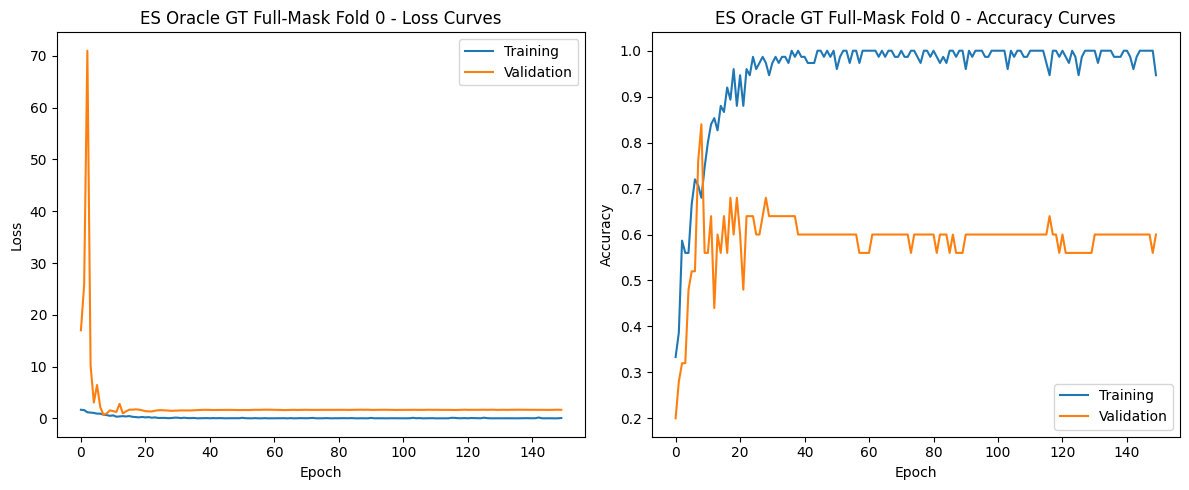


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.8000    0.8000    0.8000         5
         DCM     0.8333    1.0000    0.9091         5
         HCM     1.0000    1.0000    1.0000         5
          MI     1.0000    0.4000    0.5714         5
         NOR     0.7143    1.0000    0.8333         5

    accuracy                         0.8400        25
   macro avg     0.8695    0.8400    0.8228        25
weighted avg     0.8695    0.8400    0.8228        25



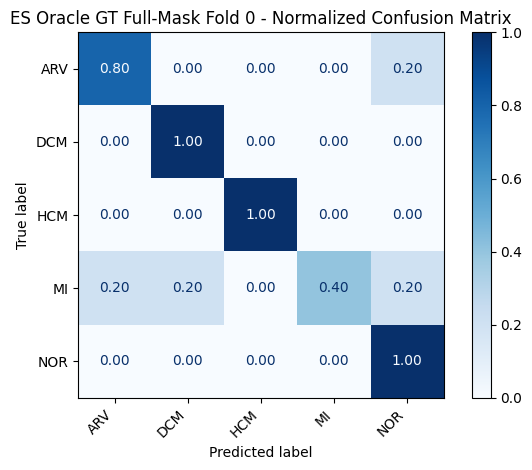


FOLD 1
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=20.00%  val_acc=20.00%  val_f1=6.67%
Epoch 002/150  train_acc=30.67%  val_acc=20.00%  val_f1=6.67%
Epoch 003/150  train_acc=40.00%  val_acc=20.00%  val_f1=6.67%
Epoch 004/150  train_acc=65.33%  val_acc=40.00%  val_f1=26.52%
Epoch 005/150  train_acc=64.00%  val_acc=40.00%  val_f1=34.67%
Epoch 006/150  train_acc=72.00%  val_acc=44.00%  val_f1=37.54%
Epoch 007/150  train_acc=73.33%  val_acc=40.00%  val_f1=29.10%
Epoch 008/150  train_acc=69.33%  val_acc=64.00%  val_f1=54.80%
Epoch 009/150  train_acc=73.33%  val_acc=68.00%  val_f1=60.68%
Epoch 010/150  train_acc=80.00%  val_acc=64.00%  val_f1=62.18%
Epoch 011/150  train_acc=80.00%  val_acc=68.00%  val_f1=61.45%
Epoch 012/150  train_acc=85.33%  val_acc=60.00%  val_f1=56.19%
Epoch 013/150  train_acc=77.33%  val_acc=76.00%  val_f1=76.64%
Epoch 014/150  train_acc=86.67%  val_acc=64.00%  val_f1=62.03%
Epoch 015/150  train_acc=92.00%  val_acc=64.00%  val_f1=60.53%
Ep

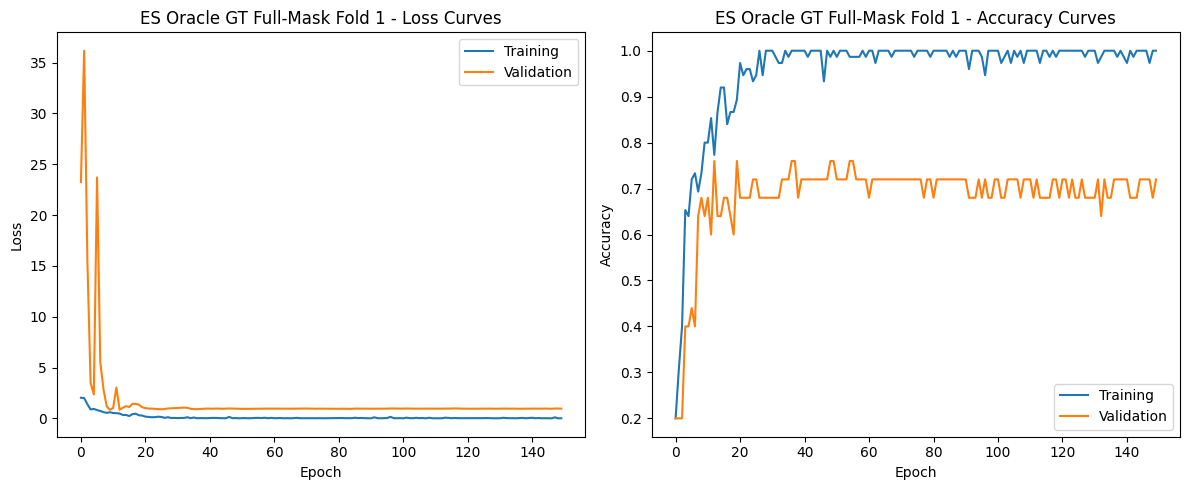


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     1.0000    0.6000    0.7500         5
         DCM     1.0000    1.0000    1.0000         5
         HCM     0.8000    0.8000    0.8000         5
          MI     0.7500    0.6000    0.6667         5
         NOR     0.5000    0.8000    0.6154         5

    accuracy                         0.7600        25
   macro avg     0.8100    0.7600    0.7664        25
weighted avg     0.8100    0.7600    0.7664        25



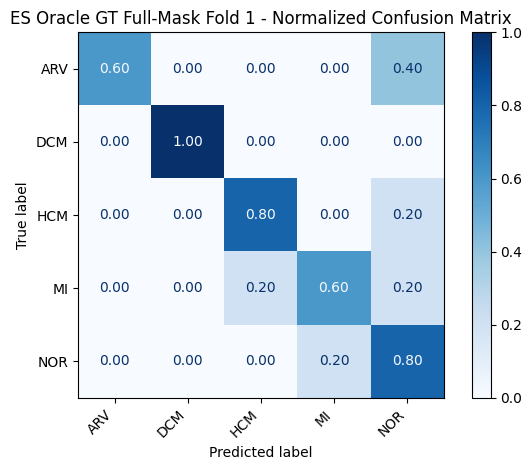


FOLD 2
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=29.33%  val_acc=24.00%  val_f1=12.00%
Epoch 002/150  train_acc=30.67%  val_acc=32.00%  val_f1=19.33%
Epoch 003/150  train_acc=53.33%  val_acc=36.00%  val_f1=23.62%
Epoch 004/150  train_acc=66.67%  val_acc=48.00%  val_f1=36.26%
Epoch 005/150  train_acc=61.33%  val_acc=48.00%  val_f1=40.00%
Epoch 006/150  train_acc=64.00%  val_acc=44.00%  val_f1=36.24%
Epoch 007/150  train_acc=76.00%  val_acc=36.00%  val_f1=30.36%
Epoch 008/150  train_acc=69.33%  val_acc=52.00%  val_f1=52.69%
Epoch 009/150  train_acc=86.67%  val_acc=52.00%  val_f1=47.14%
Epoch 010/150  train_acc=81.33%  val_acc=56.00%  val_f1=58.27%
Epoch 011/150  train_acc=77.33%  val_acc=48.00%  val_f1=42.68%
Epoch 012/150  train_acc=82.67%  val_acc=72.00%  val_f1=66.32%
Epoch 013/150  train_acc=84.00%  val_acc=64.00%  val_f1=59.18%
Epoch 014/150  train_acc=93.33%  val_acc=72.00%  val_f1=71.09%
Epoch 015/150  train_acc=89.33%  val_acc=48.00%  val_f1=43.93%

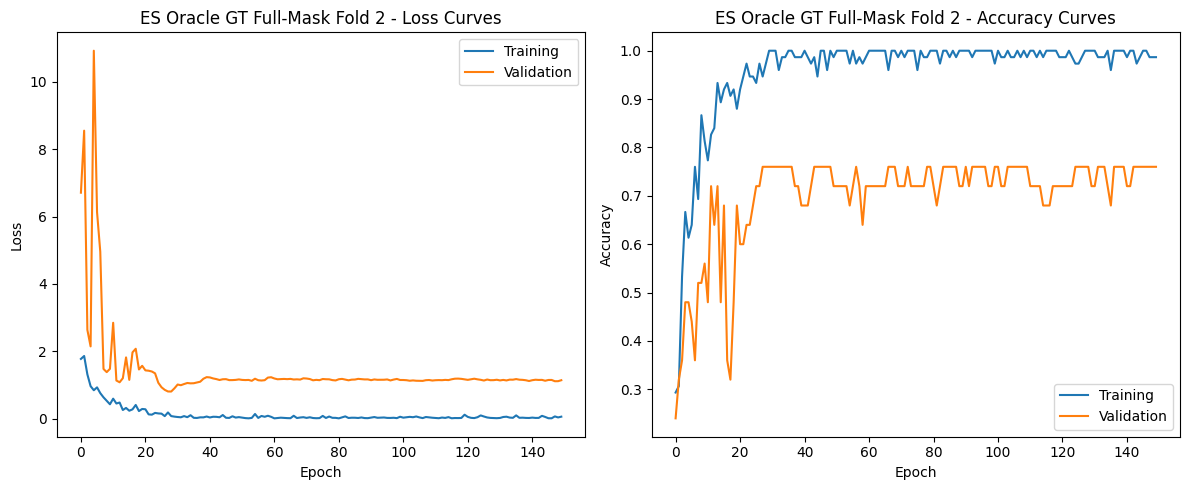


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     1.0000    0.6000    0.7500         5
         DCM     0.6667    0.8000    0.7273         5
         HCM     1.0000    0.8000    0.8889         5
          MI     0.7500    0.6000    0.6667         5
         NOR     0.6250    1.0000    0.7692         5

    accuracy                         0.7600        25
   macro avg     0.8083    0.7600    0.7604        25
weighted avg     0.8083    0.7600    0.7604        25



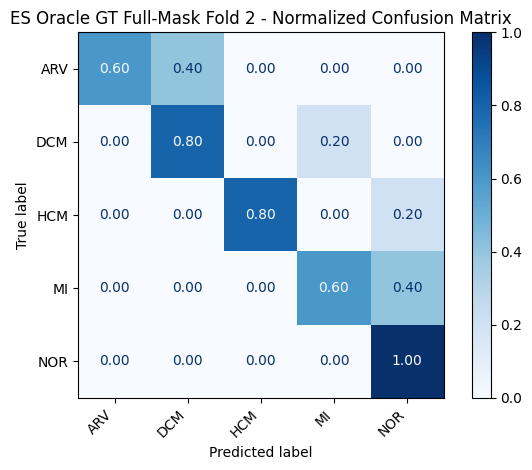


FOLD 3
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=21.33%  val_acc=20.00%  val_f1=6.67%
Epoch 002/150  train_acc=29.33%  val_acc=20.00%  val_f1=6.67%
Epoch 003/150  train_acc=56.00%  val_acc=32.00%  val_f1=19.10%
Epoch 004/150  train_acc=57.33%  val_acc=24.00%  val_f1=12.41%
Epoch 005/150  train_acc=62.67%  val_acc=36.00%  val_f1=24.70%
Epoch 006/150  train_acc=73.33%  val_acc=32.00%  val_f1=22.42%
Epoch 007/150  train_acc=73.33%  val_acc=52.00%  val_f1=40.29%
Epoch 008/150  train_acc=84.00%  val_acc=40.00%  val_f1=24.29%
Epoch 009/150  train_acc=81.33%  val_acc=44.00%  val_f1=30.81%
Epoch 010/150  train_acc=85.33%  val_acc=40.00%  val_f1=33.02%
Epoch 011/150  train_acc=77.33%  val_acc=48.00%  val_f1=42.97%
Epoch 012/150  train_acc=81.33%  val_acc=56.00%  val_f1=50.66%
Epoch 013/150  train_acc=76.00%  val_acc=52.00%  val_f1=45.20%
Epoch 014/150  train_acc=82.67%  val_acc=44.00%  val_f1=40.32%
Epoch 015/150  train_acc=94.67%  val_acc=52.00%  val_f1=45.40%
E

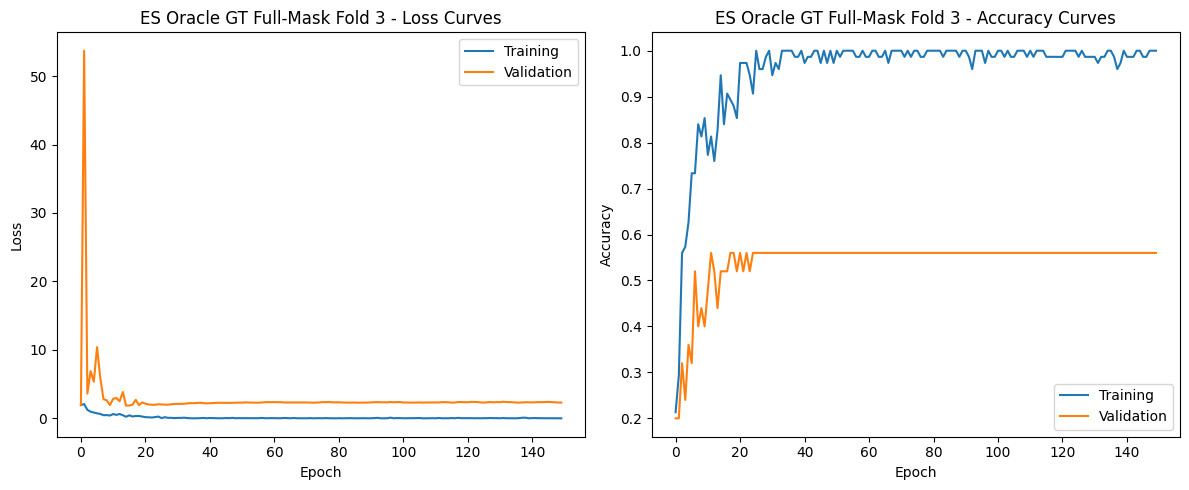


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     1.0000    0.6000    0.7500         5
         DCM     0.6667    0.8000    0.7273         5
         HCM     0.3846    1.0000    0.5556         5
          MI     0.0000    0.0000    0.0000         5
         NOR     0.6667    0.4000    0.5000         5

    accuracy                         0.5600        25
   macro avg     0.5436    0.5600    0.5066        25
weighted avg     0.5436    0.5600    0.5066        25



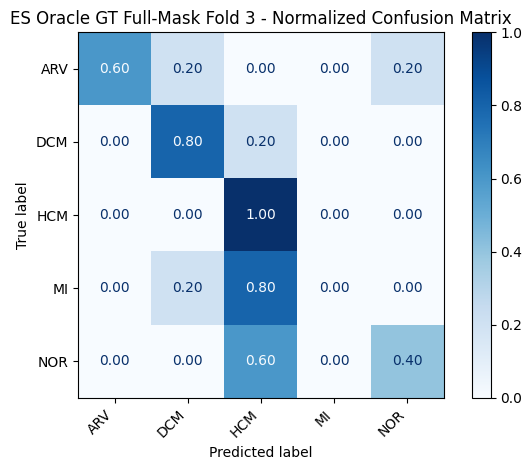


ES SEGMENTATION-GUIDED TRAINING SUMMARY (4 FOLDS, V5)
Fold 0 | Val Acc =  84.00% | Macro F1 =  82.28% | Macro Sens =  84.00% | Macro Spec =  96.00%
Fold 1 | Val Acc =  76.00% | Macro F1 =  76.64% | Macro Sens =  76.00% | Macro Spec =  94.00%
Fold 2 | Val Acc =  76.00% | Macro F1 =  76.04% | Macro Sens =  76.00% | Macro Spec =  94.00%
Fold 3 | Val Acc =  56.00% | Macro F1 =  50.66% | Macro Sens =  56.00% | Macro Spec =  89.00%

Mean ± Std across folds
Accuracy         : 73.00 ± 11.94
Macro F1-score   : 71.40 ± 14.11
Macro sensitivity: 73.00 ± 11.94
Macro specificity: 93.25 ± 2.99


In [8]:
import os
import json
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    recall_score
)

# ===================== DEVICE =====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ===================== CLASS NAMES =====================
class_names_ES = CLASS_NAMES
print("Classes:", class_names_ES)

# ===================== OUTPUT DIRS =====================
CKPT_DIR = "./checkpoints_ES_oracle_gtfullmask_v1"
FIG_DIR = "./figures_ES_oracle_gtfullmask_v1"
META_DIR = "./fold_meta_ES_oracle_gtfullmask_v1"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

# ===================== TRAINING PARAMETERS =====================
num_epochs = 150
batch_size = 20
num_classes = 5
initial_lr = 1e-3

results_val_acc_ES_oracle_gtfullmask_v1 = {}
results_val_f1macro_ES_oracle_gtfullmask_v1 = {}
results_val_sensmacro_ES_oracle_gtfullmask_v1 = {}
results_val_specmacro_ES_oracle_gtfullmask_v1 = {}

print("\nStarting 4-fold training for ES oracle GT full-mask model (V1)...\n")

# ===================== HELPER: MACRO SPECIFICITY =====================
def macro_specificity_score(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))


# ===================== MAIN TRAINING LOOP =====================
for fold in range(4):
    print(f"\n{'='*80}")
    print(f"FOLD {fold}")
    print(f"{'='*80}")
    print(f"Training samples   : {len(fold_train_dataset_ES[fold])}")
    print(f"Validation samples : {len(fold_val_dataset_ES[fold])}")

    trainloader = DataLoader(
        fold_train_dataset_ES[fold],
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    valloader = DataLoader(
        fold_val_dataset_ES[fold],
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    dataloaders = {
        "train": trainloader,
        "val": valloader
    }

    dataset_sizes = {
        "train": len(fold_train_dataset_ES[fold]),
        "val": len(fold_val_dataset_ES[fold])
    }

    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    best_val_f1 = 0.0
    best_val_sens = 0.0
    best_val_spec = 0.0
    best_epoch = -1

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    # ===================== EPOCH LOOP =====================
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1:03d}/{num_epochs}", end="  ")

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            y_true_all = []
            y_pred_all = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * labels.size(0)
                running_corrects += torch.sum(preds == labels.data)

                y_true_all.extend(labels.detach().cpu().numpy().tolist())
                y_pred_all.extend(preds.detach().cpu().numpy().tolist())

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double().item() / dataset_sizes[phase]

            if phase == "train":
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc)
                print(f"train_acc={epoch_acc*100:.2f}%", end="  ")
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc)

                val_f1_macro = f1_score(y_true_all, y_pred_all, average="macro")
                val_sens_macro = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
                val_spec_macro = macro_specificity_score(y_true_all, y_pred_all, num_classes=num_classes)

                # PAPER-STYLE ES LOGIC: save best checkpoint by validation accuracy
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_val_f1 = val_f1_macro
                    best_val_sens = val_sens_macro
                    best_val_spec = val_spec_macro
                    best_epoch = epoch + 1
                    best_model_wts = copy.deepcopy(model.state_dict())

                    ckpt_path = os.path.join(
                        CKPT_DIR,
                        f"ES-oracle-gtfullmask-resnet50-best-fold-{fold}_v5.pth"
                    )
                    torch.save(best_model_wts, ckpt_path)

                print(f"val_acc={epoch_acc*100:.2f}%  val_f1={val_f1_macro*100:.2f}%")

    # ===================== LOAD BEST CHECKPOINT =====================
    model.load_state_dict(best_model_wts)

    results_val_acc_ES_oracle_gtfullmask_v1[fold] = float(best_val_acc * 100)
    results_val_f1macro_ES_oracle_gtfullmask_v1[fold] = float(best_val_f1 * 100)
    results_val_sensmacro_ES_oracle_gtfullmask_v1[fold] = float(best_val_sens * 100)
    results_val_specmacro_ES_oracle_gtfullmask_v1[fold] = float(best_val_spec * 100)

    # ===================== SAVE METADATA =====================
    fold_meta = {
        "fold": fold,
        "model_selection_metric_within_fold": "validation_accuracy",
        "best_epoch": int(best_epoch),
        "best_val_accuracy": float(best_val_acc * 100),
        "best_val_macro_f1": float(best_val_f1 * 100),
        "best_val_macro_sensitivity": float(best_val_sens * 100),
        "best_val_macro_specificity": float(best_val_spec * 100),
        "checkpoint_path": os.path.join(
            CKPT_DIR,
            f"ES-oracle-gtfullmask-resnet50-best-fold-{fold}_v5.pth"
        )
    }

    with open(os.path.join(META_DIR, f"ES_oracle_gtfullmask_fold_{fold}_meta_v5.json"), "w", encoding="utf-8") as f:
        json.dump(fold_meta, f, indent=2)

    print("\nBest fold checkpoint summary")
    print(f"Best epoch              : {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
    print(f"Best validation macro F1: {best_val_f1*100:.2f}%")
    print(f"Best validation macro sensitivity: {best_val_sens*100:.2f}%")
    print(f"Best validation macro specificity: {best_val_spec*100:.2f}%")

    # ===================== CURVES =====================
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].plot(train_loss_history, label="Training")
    axs[0].plot(val_loss_history, label="Validation")
    axs[0].set_title(f"ES Oracle GT Full-Mask Fold {fold} - Loss Curves")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()

    axs[1].plot(train_acc_history, label="Training")
    axs[1].plot(val_acc_history, label="Validation")
    axs[1].set_title(f"ES Oracle GT Full-Mask Fold {fold} - Accuracy Curves")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"ES_oracle_gtfullmask_fold{fold}_loss_accuracy_curves_v5.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # ===================== VALIDATION REPORT =====================
    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu()

            y_true_all.extend(labels.tolist())
            y_pred_all.extend(preds.tolist())

    print("\nClassification Report (Validation Set, Best Checkpoint):")
    print(classification_report(
        y_true_all,
        y_pred_all,
        target_names=class_names_ES,
        digits=4,
        zero_division=0
    ))

    disp = ConfusionMatrixDisplay.from_predictions(
        y_true_all,
        y_pred_all,
        display_labels=class_names_ES,
        cmap=plt.cm.Blues,
        normalize="true",
        values_format=".2f"
    )
    disp.ax_.set_title(f"ES Oracle GT Full-Mask Fold {fold} - Normalized Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"ES_oracle_gtfullmask_fold{fold}_normalized_confusion_matrix_v5.png"), dpi=300, bbox_inches="tight")
    plt.show()

# ===================== FINAL SUMMARY =====================
print("\n" + "="*90)
print("ES SEGMENTATION-GUIDED TRAINING SUMMARY (4 FOLDS, V5)")
print("="*90)

for f in range(4):
    print(
        f"Fold {f} | "
        f"Val Acc = {results_val_acc_ES_oracle_gtfullmask_v1[f]:6.2f}% | "
        f"Macro F1 = {results_val_f1macro_ES_oracle_gtfullmask_v1[f]:6.2f}% | "
        f"Macro Sens = {results_val_sensmacro_ES_oracle_gtfullmask_v1[f]:6.2f}% | "
        f"Macro Spec = {results_val_specmacro_ES_oracle_gtfullmask_v1[f]:6.2f}%"
    )

acc_values = np.array(list(results_val_acc_ES_oracle_gtfullmask_v1.values()))
f1_values = np.array(list(results_val_f1macro_ES_oracle_gtfullmask_v1.values()))
sens_values = np.array(list(results_val_sensmacro_ES_oracle_gtfullmask_v1.values()))
spec_values = np.array(list(results_val_specmacro_ES_oracle_gtfullmask_v1.values()))

print("\nMean ± Std across folds")
print(f"Accuracy         : {acc_values.mean():.2f} ± {acc_values.std(ddof=1):.2f}")
print(f"Macro F1-score   : {f1_values.mean():.2f} ± {f1_values.std(ddof=1):.2f}")
print(f"Macro sensitivity: {sens_values.mean():.2f} ± {sens_values.std(ddof=1):.2f}")
print(f"Macro specificity: {spec_values.mean():.2f} ± {spec_values.std(ddof=1):.2f}")


### 5. Final Evaluation of the ES Single-Phase Model  
**Held-Out Test Set Performance**

#### Overview
This section evaluates the final ES single-phase classification model on the official held-out test set.

#### Model Selection Strategy
- The selected ES configuration is **ResNet-50 with Adam and an initial learning rate of 0.001**
- Four fold-specific models are available from cross-validation training
- The final model is selected using the **highest validation macro F1-score** among the four folds
- The test set is used only for the final evaluation of the selected fold

#### Evaluation Outputs
- overall test accuracy
- macro F1-score
- macro sensitivity
- macro specificity
- full classification report
- normalized confusion matrix
- bootstrap summary based on 1000 resamples

#### Purpose
The goal of this stage is to measure how well the final ES model generalizes to previously unseen subjects in the held-out test set.

Validation macro F1-score per fold:
Fold 0: 82.28%
Fold 1: 76.64%
Fold 2: 76.04%
Fold 3: 50.66%

Selected fold for final ES oracle GT full-mask test evaluation: Fold 0
Selection criterion: highest validation macro F1-score = 82.28%
Loading checkpoint: checkpoints_ES_oracle_gtfullmask_v1\ES-oracle-gtfullmask-resnet50-best-fold-0_v5.pth

=== SINGLE RUN ON TEST SET (50 subjects) ===
Accuracy          : 62.00%
Macro F1-score    : 59.89%
Macro Sensitivity : 62.00%
Macro Specificity : 90.50%

Classification Report (Test Set):
              precision    recall  f1-score   support

         ARV     0.6154    0.8000    0.6957        10
         DCM     0.6250    1.0000    0.7692        10
         HCM     0.8571    0.6000    0.7059        10
          MI     0.5714    0.4000    0.4706        10
         NOR     0.4286    0.3000    0.3529        10

    accuracy                         0.6200        50
   macro avg     0.6195    0.6200    0.5989        50
weighted avg     0.6195    0.6200    0.5

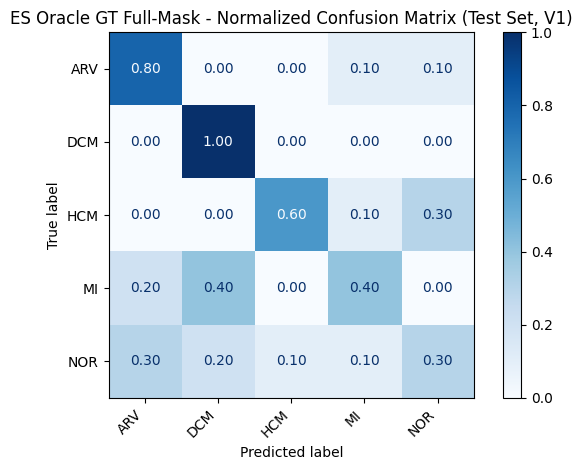

In [9]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)
import matplotlib.pyplot as plt

# ===================== DEVICE =====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 5

# ===================== CHECKPOINT DIR =====================
CKPT_DIR = Path("./checkpoints_ES_oracle_gtfullmask_v1")

# ===================== HELPER =====================
def macro_specificity_score(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)

    return float(np.mean(specs))

# ===================== SELECT FINAL FOLD BY VALIDATION MACRO F1 =====================
best_fold = max(results_val_f1macro_ES_oracle_gtfullmask_v1, key=results_val_f1macro_ES_oracle_gtfullmask_v1.get)

print("Validation macro F1-score per fold:")
for f in sorted(results_val_f1macro_ES_oracle_gtfullmask_v1.keys()):
    print(f"Fold {f}: {results_val_f1macro_ES_oracle_gtfullmask_v1[f]:.2f}%")

print(f"\nSelected fold for final ES oracle GT full-mask test evaluation: Fold {best_fold}")
print(f"Selection criterion: highest validation macro F1-score = {results_val_f1macro_ES_oracle_gtfullmask_v1[best_fold]:.2f}%")

# ===================== TEST LOADER =====================
testloader_ES = DataLoader(
    fold_test_dataset_ES[best_fold],
    batch_size=25,
    shuffle=False,
    num_workers=0
)

# ===================== LOAD MODEL =====================
ckpt_path = CKPT_DIR / f"ES-oracle-gtfullmask-resnet50-best-fold-{best_fold}_v5.pth"
print("Loading checkpoint:", ckpt_path)

if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

model_ES = models.resnet50(weights="IMAGENET1K_V1")
model_ES.fc = nn.Linear(model_ES.fc.in_features, NUM_CLASSES)
model_ES.load_state_dict(torch.load(ckpt_path, map_location=device))
model_ES = model_ES.to(device)
model_ES.eval()

# ===================== EVALUATION =====================
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in testloader_ES:
        inputs = inputs.to(device)
        outputs = model_ES(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred) * 100
macro_f1 = f1_score(y_true, y_pred, average="macro") * 100
macro_spec = macro_specificity_score(y_true, y_pred, num_classes=NUM_CLASSES) * 100
macro_sens = recall_score(y_true, y_pred, average="macro", zero_division=0) * 100

print("\n=== SINGLE RUN ON TEST SET (50 subjects) ===")
print(f"Accuracy          : {acc:.2f}%")
print(f"Macro F1-score    : {macro_f1:.2f}%")
print(f"Macro Sensitivity : {macro_sens:.2f}%")
print(f"Macro Specificity : {macro_spec:.2f}%")

print("\nClassification Report (Test Set):")
print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=CLASS_NAMES,
    cmap=plt.cm.Blues,
    normalize="true",
    values_format=".2f"
)
disp.ax_.set_title("ES Oracle GT Full-Mask - Normalized Confusion Matrix (Test Set, V1)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ES_oracle_gtfullmask_test_normalized_confusion_matrix_v1.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# ===================== BOOTSTRAP PARAMETERS =====================
n_bootstrap = 1000
rng = np.random.default_rng(seed=42)

bootstrap_acc = []
bootstrap_f1 = []
bootstrap_sens = []
bootstrap_spec = []

def macro_specificity_score(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)

    return float(np.mean(specs))

print("\nRunning bootstrap resampling (n=1000)...")

n = len(y_true)

for _ in range(n_bootstrap):

    idx = rng.integers(0, n, n)

    y_true_bs = y_true[idx]
    y_pred_bs = y_pred[idx]

    acc = accuracy_score(y_true_bs, y_pred_bs) * 100
    f1 = f1_score(y_true_bs, y_pred_bs, average="macro") * 100
    sens = recall_score(y_true_bs, y_pred_bs, average="macro", zero_division=0) * 100
    spec = macro_specificity_score(y_true_bs, y_pred_bs) * 100

    bootstrap_acc.append(acc)
    bootstrap_f1.append(f1)
    bootstrap_sens.append(sens)
    bootstrap_spec.append(spec)

bootstrap_acc = np.array(bootstrap_acc)
bootstrap_f1 = np.array(bootstrap_f1)
bootstrap_sens = np.array(bootstrap_sens)
bootstrap_spec = np.array(bootstrap_spec)

print("\n=== BOOTSTRAP TEST RESULTS (n=1000) ===")
print(f"Accuracy          : {bootstrap_acc.mean():.2f} ± {bootstrap_acc.std():.2f}   (min {bootstrap_acc.min():.2f} / max {bootstrap_acc.max():.2f})")
print(f"Macro F1-score    : {bootstrap_f1.mean():.2f} ± {bootstrap_f1.std():.2f}   (min {bootstrap_f1.min():.2f} / max {bootstrap_f1.max():.2f})")
print(f"Macro Sensitivity : {bootstrap_sens.mean():.2f} ± {bootstrap_sens.std():.2f}   (min {bootstrap_sens.min():.2f} / max {bootstrap_sens.max():.2f})")
print(f"Macro Specificity : {bootstrap_spec.mean():.2f} ± {bootstrap_spec.std():.2f}   (min {bootstrap_spec.min():.2f} / max {bootstrap_spec.max():.2f})")



Running bootstrap resampling (n=1000)...

=== BOOTSTRAP TEST RESULTS (n=1000) ===
Accuracy          : 62.28 ± 6.88   (min 40.00 / max 84.00)
Macro F1-score    : 58.74 ± 6.93   (min 38.41 / max 81.34)
Macro Sensitivity : 62.09 ± 6.27   (min 41.79 / max 84.58)
Macro Specificity : 90.57 ± 1.69   (min 85.42 / max 96.15)
